# Trajectory Inference with VIA

VIA (Velocity and Topology Inference Algorithm) is a single-cell trajectory inference method for topology construction, pseudotime estimation, automatic terminal-state prediction, and visualization of temporal gene dynamics along lineages. This tutorial follows the example data and analysis workflow provided by the VIA authors, while using the OmicVerse wrapper interface for a more direct `AnnData` workflow.

If you use VIA in your research, please cite:

[Generalized and scalable trajectory inference in single-cell omics data with VIA](https://www.nature.com/articles/s41467-021-25773-3)

Code repository: <https://github.com/ShobiStassen/VIA>

Reproducible Colab tutorial: <https://colab.research.google.com/drive/1A2X23z_RLJaYLbXaiCbZa-fjNbuGACrD?usp=sharing>

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov

warnings.filterwarnings("ignore", category=FutureWarning)

ov.plot_set(font_path='Arial')
Path("figures").mkdir(exist_ok=True)

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Data Loading and Preprocessing

This tutorial uses the `scRNA_hematopoiesis` hematopoietic development dataset provided by the VIA authors. The data have already been normalized and log-transformed, but not scaled. After loading the dataset, we compute PCA; VIA will use `adata.obsm["X_pca"]` as the cell feature space.

In [2]:
adata = ov.single.scRNA_hematopoiesis()
sc.tl.pca(adata, svd_solver='arpack', n_comps=200)
adata

Cell type PRE_B2 has  515 cells
Cell type MONO1 has  186 cells
Cell type GMP has  28 cells
Cell type EOS2 has  3 cells
Cell type ERY4 has  53 cells
Cell type mDC (cDC) has  96 cells
Cell type GRAN1 has  3 cells
Cell type BASO1 has  2 cells
Cell type B_a1 has  27 cells
Cell type B_a4 has  8 cells
Cell type PRE_B3 has  2 cells
Cell type ERY3 has  104 cells
Cell type MONO2 has  35 cells
Cell type HSC1 has  2365 cells
Cell type MEP has  339 cells
Cell type ERY1 has  773 cells
Cell type HSC2 has  10 cells
Cell type MEGA1 has  12 cells
Cell type CMP has  968 cells
Cell type pDC has  204 cells
Cell type B_a2 has  1 cells
Cell type Nka3 has  5 cells
Cell type ERY2 has  40 cells
Cell type TCEL7 has  1 cells


AnnData object with n_obs × n_vars = 5780 × 14651
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'label'
    uns: 'cluster_colors', 'ct_colors', 'palantir_branch_probs_cell_types', 'pca'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs', 'X_pca'
    varm: 'PCs'

## Model Construction and Run

VIA needs a cell feature matrix for trajectory inference, such as `X_pca`, `X_scVI`, or `X_glue`. Here we use `X_pca` and set `adata_ncomps=80` to use the first 80 principal components.

We also specify the cell annotation column used for coloring and graph summaries through `clusters`; this tutorial uses `adata.obs["label"]`. If `root_user` is not provided, VIA attempts to choose the root cell automatically. Here the root cell index is set explicitly to reproduce the author example. The two-dimensional visualization coordinates are selected with `basis`; this dataset provides `adata.obsm["tsne"]`.

For more parameter details, see the VIA documentation: <https://pyvia.readthedocs.io/en/latest/Parameters%20and%20Attributes.html>

In [8]:
v0 = ov.single.pyVIA(
    adata=adata,
    adata_key='X_pca',
    adata_ncomps=80,
    basis='tsne',
    clusters='label',
    knn=30,
    random_seed=4,
    root_user=[4823],
)

v0.run()

2026-05-23 00:15:53.139373	Running VIA over input data of 5780 (samples) x 80 (features)
2026-05-23 00:15:53.139707	Knngraph has 30 neighbors
2026-05-23 00:15:55.565303	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 46.3 % of edges. 
2026-05-23 00:15:55.577221	Number of connected components used for clustergraph  is 1
2026-05-23 00:15:55.705682	Commencing community detection
2026-05-23 00:15:56.048954	Finished community detection. Found 207 clusters.
2026-05-23 00:15:56.049939	Merging 189 very small clusters (<10)
2026-05-23 00:15:56.051191	Finished detecting communities. Found 18 communities
2026-05-23 00:15:56.051347	Making cluster graph. Global cluster graph pruning level: 0.15
2026-05-23 00:15:56.058392	Graph has 1 connected components before pruning
2026-05-23 00:15:56.058911	Graph has 2 connected components after pruning
2026-05-23 00:15:56.059177	Graph has 1 connected components after reconnecting
2026-05-23 00:15:56.059300	0.0% links trimmed 

  0%|                                                                                                         …

memory for rw2 hittings times  2. Using rw2 based pt
2026-05-23 00:16:01.292715	Identifying terminal clusters corresponding to unique lineages...
2026-05-23 00:16:01.292735	Closeness:[3, 5, 7, 9, 12]
2026-05-23 00:16:01.292742	Betweenness:[1, 2, 3, 4, 7, 9, 10, 12, 14, 15, 16]
2026-05-23 00:16:01.292746	Out Degree:[3, 4, 5, 7, 9, 10, 12, 14, 15, 16]
2026-05-23 00:16:01.292808	Cluster 5 had 3 or more neighboring terminal states [7, 9, 16] and so we removed cluster 7
2026-05-23 00:16:01.292824	We removed cluster 10 from the shortlist of terminal states
2026-05-23 00:16:01.292873	Terminal clusters corresponding to unique lineages in this component are [3, 4, 5, 9, 12, 14, 15, 16] 
2026-05-23 00:16:01.292883	Calculating lineage probability at memory 5


  0%|                                                                                                         …

2026-05-23 00:16:02.555445	Cluster or terminal cell fate 3 is reached 15.0 times
2026-05-23 00:16:02.571441	Cluster or terminal cell fate 4 is reached 448.0 times
2026-05-23 00:16:02.587845	Cluster or terminal cell fate 5 is reached 85.0 times
2026-05-23 00:16:02.601460	Cluster or terminal cell fate 9 is reached 85.0 times
2026-05-23 00:16:02.613330	Cluster or terminal cell fate 12 is reached 443.0 times
2026-05-23 00:16:02.624441	Cluster or terminal cell fate 14 is reached 531.0 times
2026-05-23 00:16:02.635918	Cluster or terminal cell fate 15 is reached 507.0 times
2026-05-23 00:16:02.649561	Cluster or terminal cell fate 16 is reached 51.0 times
2026-05-23 00:16:02.652447	There are (8) terminal clusters corresponding to unique lineages {3: 'PRE_B2', 4: 'CMP', 5: 'ERY1', 9: 'ERY1', 12: 'MONO1', 14: 'pDC', 15: 'pDC', 16: 'ERY1'}
2026-05-23 00:16:02.652466	Begin projection of pseudotime and lineage likelihood
2026-05-23 00:16:03.561362	Cluster graph layout based on forward biasing
2026-

## Basic Visualization

Before drawing trajectory plots, we first inspect the cell annotations in tSNE space.

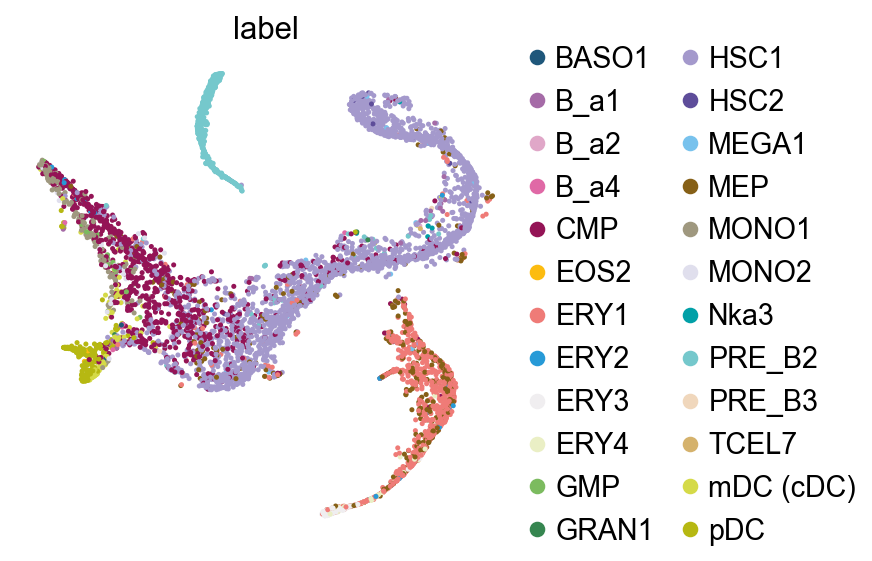

In [7]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ov.pl.embedding(
    adata,
    basis="tsne",
    color=['label'],
    frameon=False,
    ncols=1,
    wspace=0.5,
    show=False,
    ax=ax
)
fig.savefig('figures/via_fig1.png',dpi=300,bbox_inches = 'tight')

## VIA Graph

VIA provides several trajectory visualization modes. We first show the cluster-graph-level trajectory abstraction: the left panel shows the true-label composition of each VIA cluster, and the right panel shows VIA pseudotime. This view is useful for checking the global topology, root position, and terminal branches.

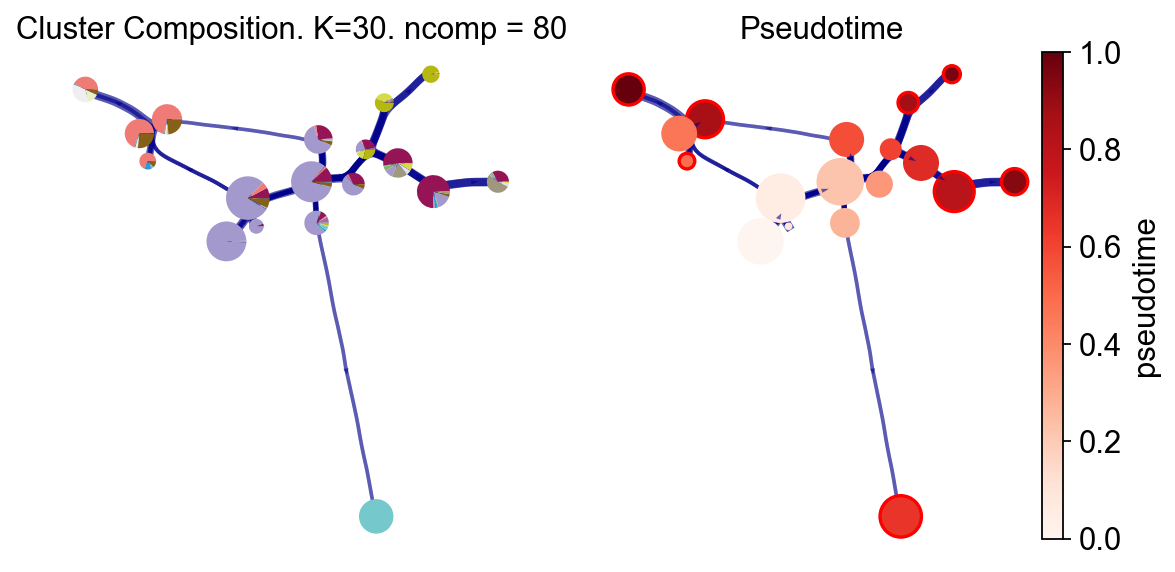

In [9]:
fig, ax, ax1 = v0.plot_piechart_graph(
    clusters='label',
    cmap='Reds',
    dpi=80,
    show_legend=False,
    ax_text=False,
    fontsize=4
)
fig.savefig('figures/via_fig2.png',dpi=300,bbox_inches = 'tight')

In [10]:
#you can use `v0.model.single_cell_pt_markov` to extract the pseudotime
v0.get_pseudotime(v0.adata)
v0.adata

...the pseudotime of VIA added to AnnData obs named `pt_via`


AnnData object with n_obs × n_vars = 5780 × 14651
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'label', 'pt_via'
    uns: 'cluster_colors', 'ct_colors', 'palantir_branch_probs_cell_types', 'pca', 'REFERENCE_MANU', 'label_colors'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs', 'X_pca'
    varm: 'PCs'

## Gene / Feature Graph Visualization

VIA can display gene expression changes along the inferred graph. Here the HNSW small-world graph built inside VIA is used to accelerate gene-expression smoothing, conceptually similar to MAGIC imputation. Selected marker genes are then projected onto the VIA cluster graph to inspect how hematopoietic programs are distributed along the trajectory.

shape of transition matrix raised to power 3 (5780, 5780)


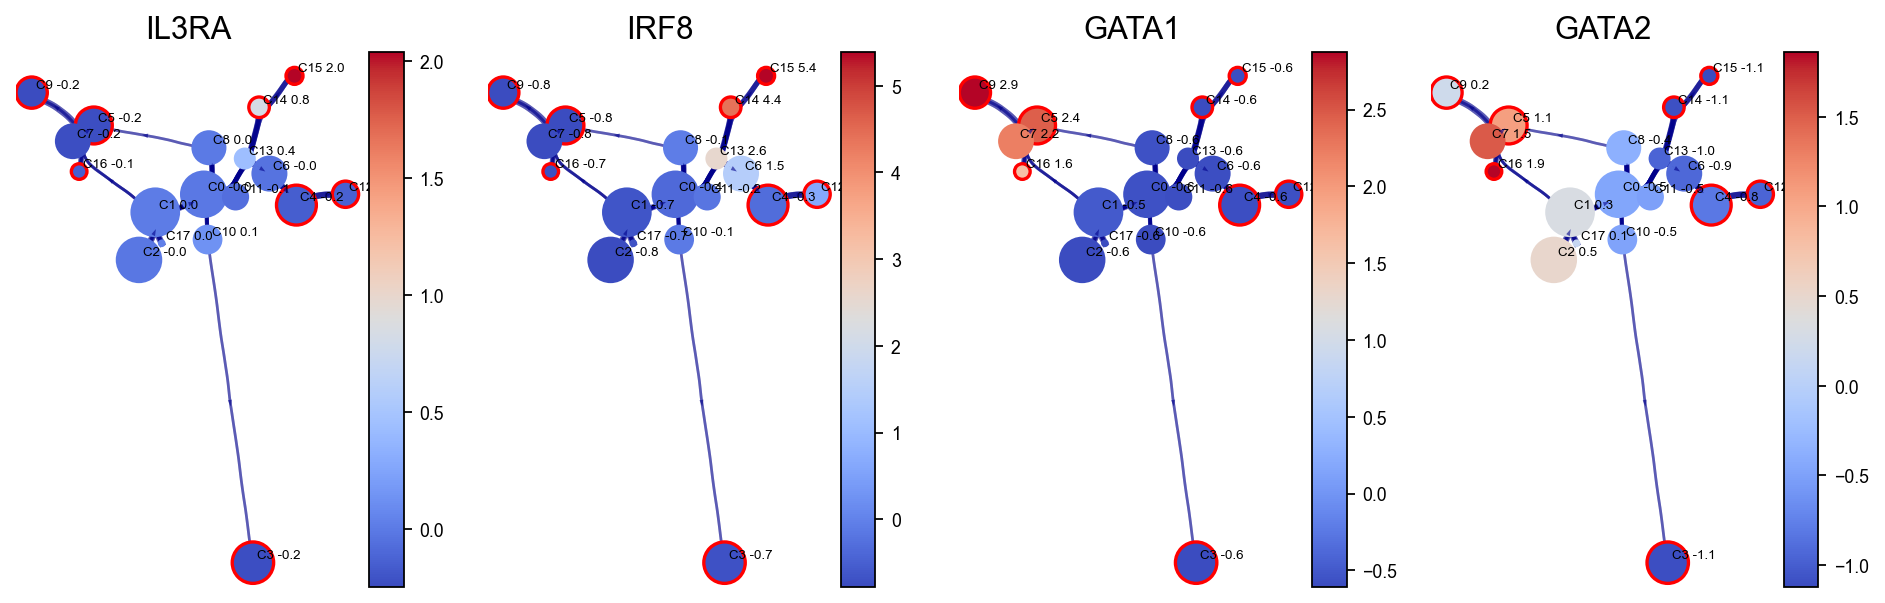

In [26]:
gene_list_magic = ['IL3RA', 'IRF8', 'GATA1', 'GATA2', 'ITGA2B', 'MPO', 'CD79B', 'SPI1', 'CD34', 'CSF1R', 'ITGAX']
fig,axs=v0.plot_clustergraph(gene_list=gene_list_magic[:4],figsize=(12,4),)
fig.savefig('figures/via_fig2_1.png',dpi=300,bbox_inches = 'tight')

## Trajectory Projection

Next, we project the VIA-inferred trajectory structure onto a two-dimensional embedding such as UMAP, PHATE, or tSNE. This section includes three views:

- overlaying the high-level cluster graph abstraction on the embedding;
- drawing a finer-grained vector-field view of cell directionality on the embedding;
- drawing high-edge-resolution directed graphs or stream plots.

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000

2026-05-23 00:16:48.944818	Super cluster 3 is a super terminal with sub_terminal cluster 3
2026-05-23 00:16:48.948985	Super cluster 4 is a super terminal with sub_terminal cluster 4
2026-05-23 00:16:48.949017	Super cluster 5 is a super terminal with sub_terminal cluster 5
2026-05-23 00:16:48.949041	Super cluster 9 is a super terminal with sub_terminal cluster 9
2026-05-23 00:16:48.949058	Super cluster 12 is a super terminal with sub_terminal cluster 12
2026-05-23 00:16:48.949075	Super cluster 14 is a super terminal with sub_terminal cluster 14
2026-05-23 00:16:48.949090	Super cluster 15 is a super terminal with sub_terminal cluster 15
2026-05-23 00:16:48.949106	Super cluster 16 is a super terminal with sub_terminal cluster 16


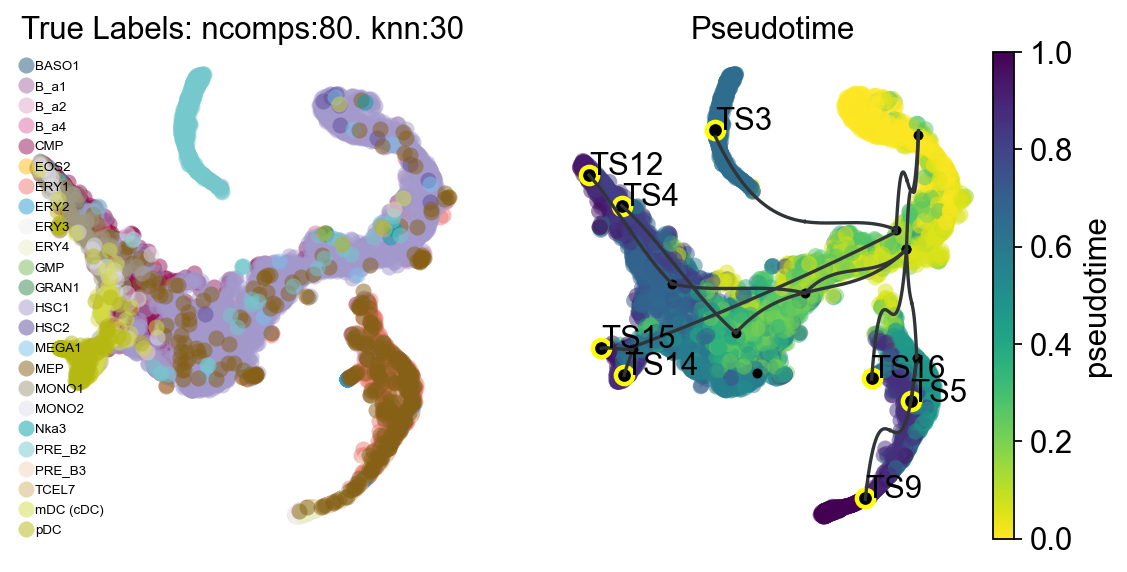

In [12]:
fig,ax1,ax2=v0.plot_trajectory_gams(basis='tsne',clusters='label',draw_all_curves=False)
fig.savefig('figures/via_fig3.png',dpi=300,bbox_inches = 'tight')

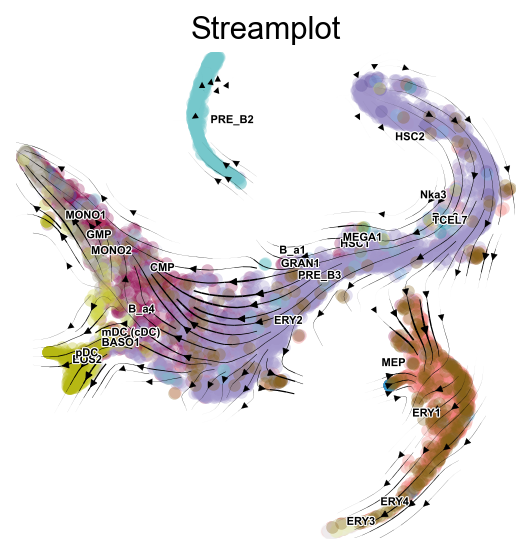

In [13]:
fig,ax=v0.plot_stream(
    basis='tsne',
    clusters='label',
    density_grid=0.8,
    scatter_size=30,
    scatter_alpha=0.3,
    linewidth=0.5
)
fig.savefig('figures/via_fig4.png',dpi=300,bbox_inches = 'tight')

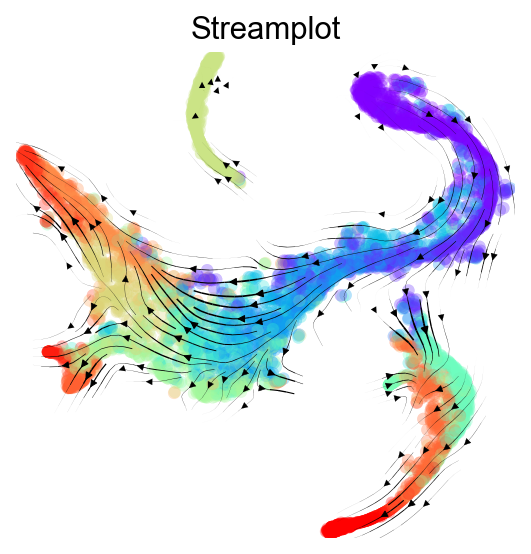

In [14]:
fig,ax=v0.plot_stream(
    basis='tsne',
    density_grid=0.8,
    scatter_size=30,
    color_scheme='time',
    linewidth=0.5,
    min_mass = 1,
    cutoff_perc = 5,
    scatter_alpha=0.3,
    marker_edgewidth=0.1,
    density_stream = 2,
    smooth_transition=1,
    smooth_grid=0.5
)
fig.savefig('figures/via_fig5.png',dpi=300,bbox_inches = 'tight')

## Probabilistic Pathways

VIA estimates lineage probabilities from the root state to terminal states. A higher lineage probability indicates greater potential for a cell to differentiate toward the corresponding terminal state. We first show probability distributions for all detected terminal lineages.

2026-05-23 00:32:09.730409	Marker_lineages: [3, 4, 5, 9, 12, 14, 15, 16]
2026-05-23 00:32:09.732605	The number of components in the original full graph is 1
2026-05-23 00:32:09.732637	For downstream visualization purposes we are also constructing a low knn-graph 
2026-05-23 00:32:12.524489	Check sc pb 1.0 
f getting majority comp
2026-05-23 00:32:12.594621	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 3: [2, 1, 0, 8, 6, 13, 10, 3]
2026-05-23 00:32:12.594638	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 4: [2, 1, 0, 11, 4]
2026-05-23 00:32:12.594645	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 5: [2, 1, 7, 5]
2026-05-23 00:32:12.594650	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 9: [2, 1, 7, 5, 9]
2026-05-23 00:32:12.594655	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 12: [2, 1, 0, 8, 6, 12]
2026-05-23 00:32:12.594660	Cluster

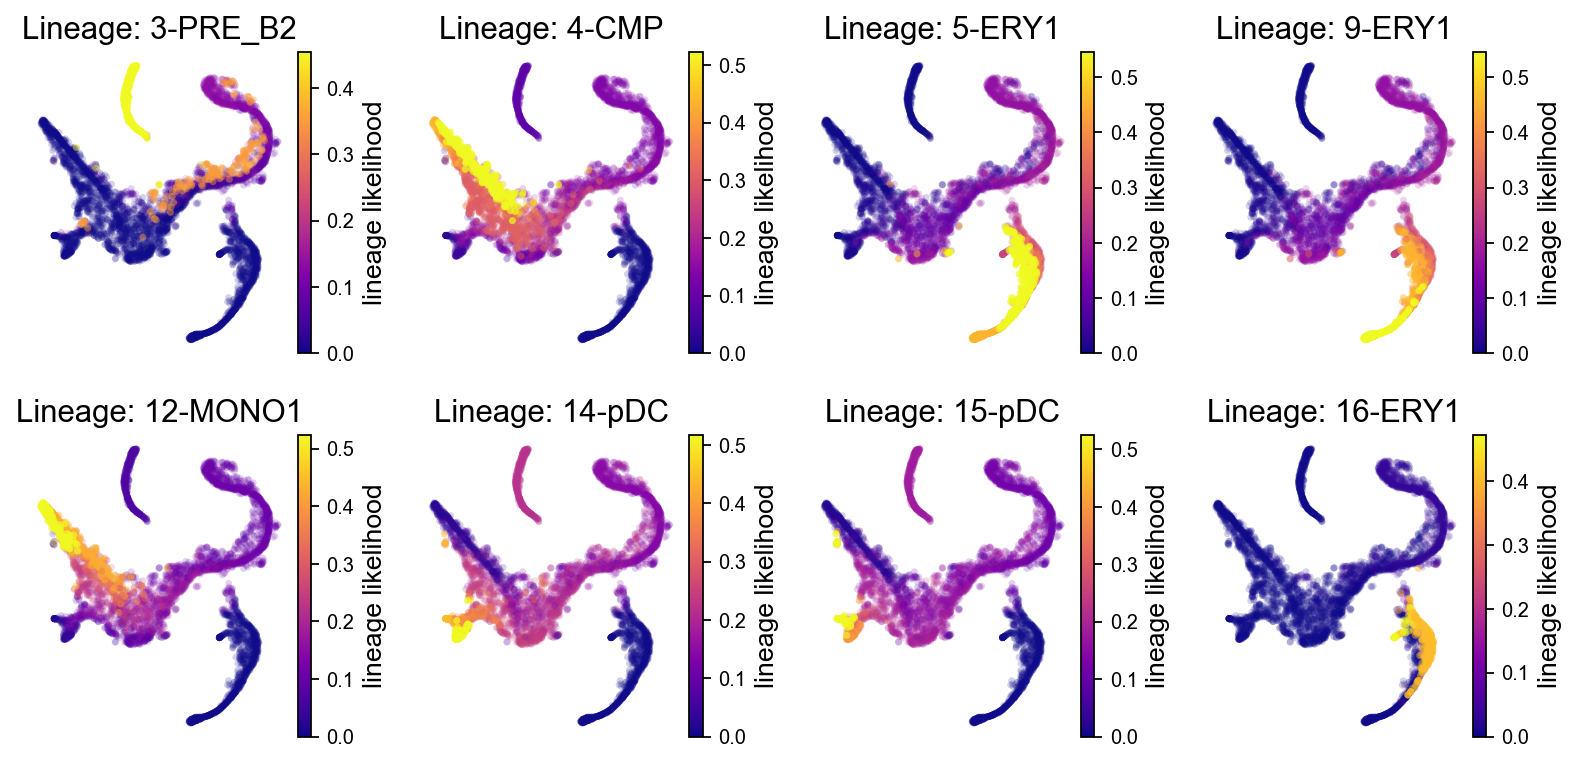

In [25]:
fig, axs = v0.plot_lineage_probability(figsize=(10, 5),ncol=4)
fig.savefig("figures/via_fig6.png", dpi=300, bbox_inches="tight")

A subset of terminal lineages can also be visualized. Here we take the first two terminal clusters detected by the fitted model, which avoids hard-coding cluster IDs that may vary across versions or random seeds.

2026-05-23 00:27:08.829986	Marker_lineages: [3, 4]
2026-05-23 00:27:08.832346	The number of components in the original full graph is 1
2026-05-23 00:27:08.832391	For downstream visualization purposes we are also constructing a low knn-graph 
2026-05-23 00:27:11.752665	Check sc pb 1.0 
f getting majority comp
2026-05-23 00:27:11.821942	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 3: [2, 1, 0, 8, 6, 13, 10, 3]
2026-05-23 00:27:11.821959	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 4: [2, 1, 0, 11, 4]
setting vmin to 0.0
2026-05-23 00:27:11.833837	Revised Cluster level path on sc-knnGraph from Root Cluster 2 to Terminal Cluster 3 along path: [2, 2, 2, 1, 10, 3, 3, 3, 3, 3]
setting vmin to 0.0
2026-05-23 00:27:11.840987	Revised Cluster level path on sc-knnGraph from Root Cluster 2 to Terminal Cluster 4 along path: [2, 2, 1, 4]


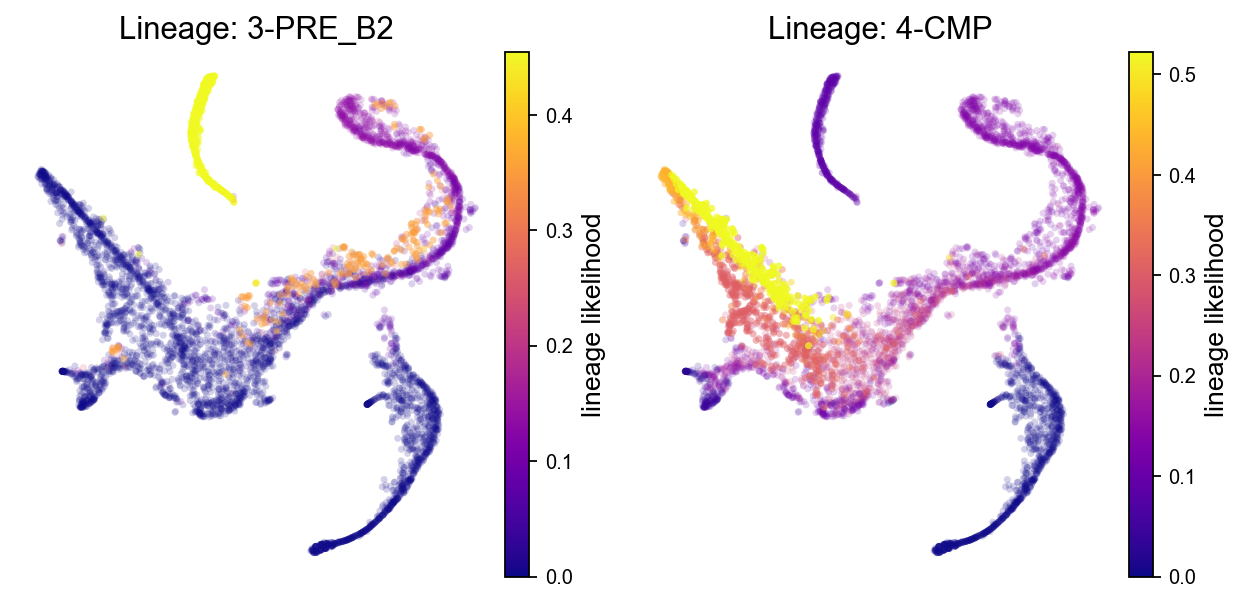

In [19]:
fig,axs=v0.plot_lineage_probability(figsize=(8,4),marker_lineages=via_marker_lineages)
fig.savefig('figures/via_fig7.png',dpi=300,bbox_inches = 'tight')

## Gene Dynamics

VIA automatically infers gene-expression trends along detected lineages. These curves can be interpreted as dynamic marker-gene programs along a specific terminal lineage. Finally, we summarize selected gene trends on specified lineages with a heatmap.

shape of transition matrix raised to power 3 (5780, 5780)


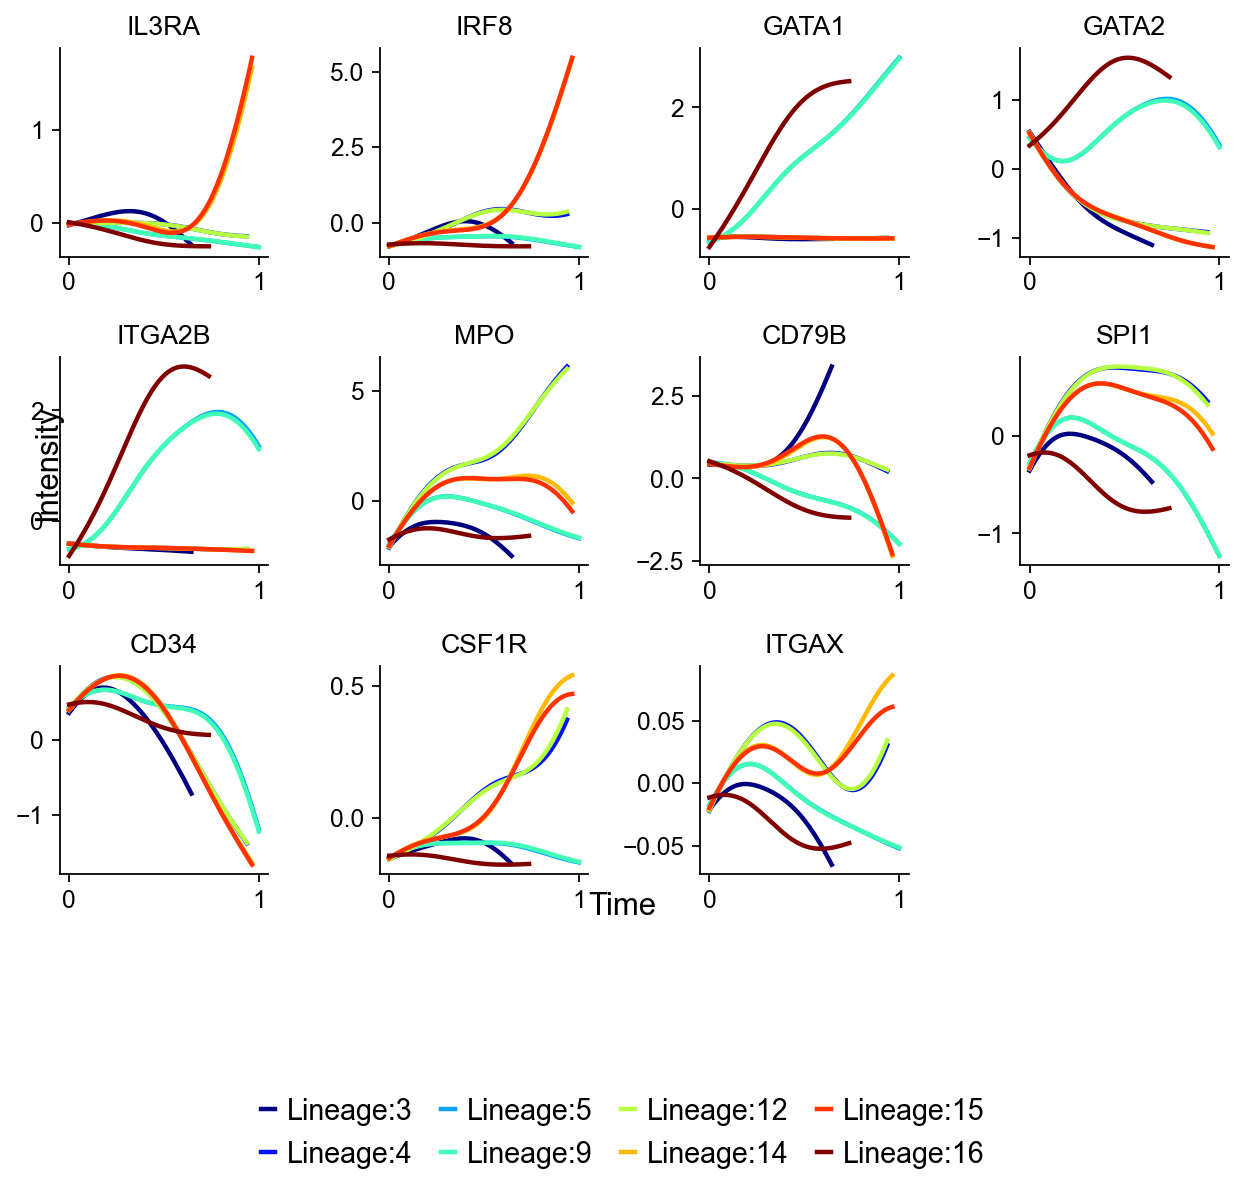

In [21]:
fig,axs=v0.plot_gene_trend(gene_list=gene_list_magic,figsize=(8,6),)
fig.savefig('figures/via_fig8.png',dpi=300,bbox_inches = 'tight')

shape of transition matrix raised to power 3 (5780, 5780)


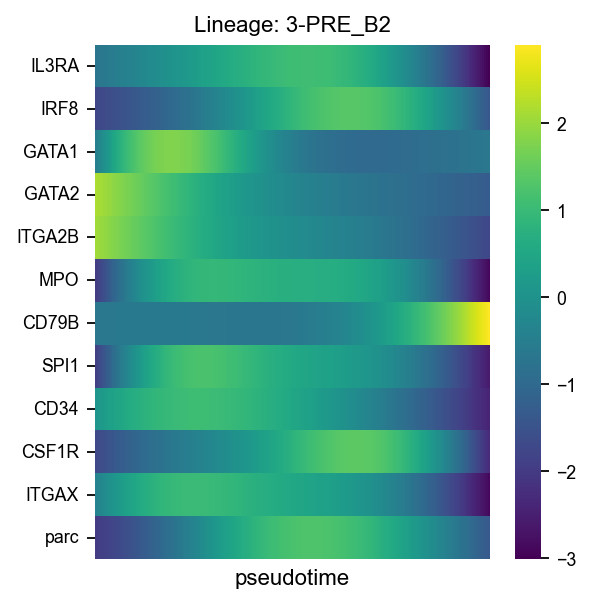

In [22]:
fig,ax=v0.plot_gene_trend_heatmap(
    gene_list=gene_list_magic,figsize=(4,4),
    marker_lineages=via_heatmap_lineages
)
fig.savefig('figures/via_fig9.png',dpi=300,bbox_inches = 'tight')